### Imports

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel

### Loading the files

In [27]:
X = np.load("initial_inputs.npy")
y = np.load("initial_outputs.npy")

### Exploring the data

In [28]:
# combining inputs and outputs into one dataFrame
df = pd.DataFrame(X, columns=["x1", "x2"])
df["y"] = y

In [29]:
df

,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


In [30]:
df.describe()

,x1,x2,y
count,10.000000,10.000000,1.000000e+01
mean,0.548817,0.539519,-3.606063e-04
std,0.259160,0.296007,1.140337e-03
min,0.082507,0.078723,-3.606063e-03
25%,0.342162,0.299421,-1.566820e-91
50%,0.612222,0.631890,6.793724e-80
75%,0.719122,0.755469,7.903833e-47
max,0.883890,0.879898,7.710875e-16


In [31]:
# printing the maximum value so far
df.loc[df["y"].idxmax()]

x1    7.310236e-01
x2    7.329999e-01
y     7.710875e-16
Name: 2, dtype: float64

### Visualising the data

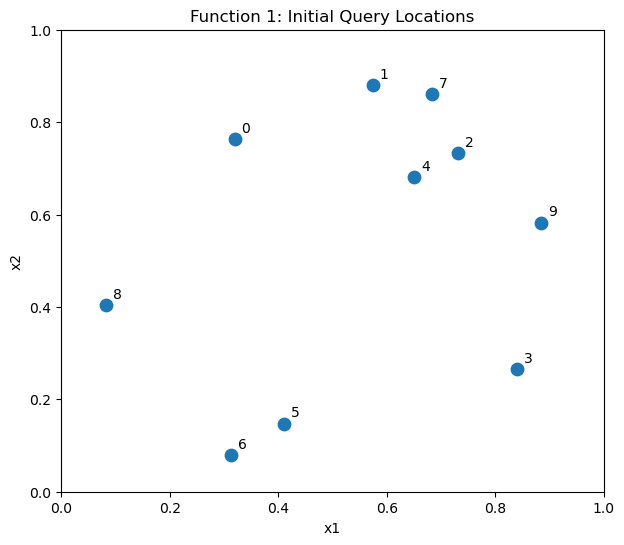

In [32]:
plt.figure(figsize=(7, 6))

plt.scatter(df["x1"], df["x2"], s=80)

for i, row in df.iterrows():
    plt.annotate(
        str(i),
        (row["x1"], row["x2"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Function 1: Initial Query Locations")
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.show()

### Bayesian optimisation - Gaussian Process

In [36]:
kernel = ConstantKernel(1.0) * Matern(
    length_scale=[0.2, 0.2],
    nu=2.5
)

In [37]:
gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

In [38]:
gp.fit(X, y)

,kernel,"1**2 * Matern... 0.2], nu=2.5)"
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,10
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,42
,kernel__k1,1**2
,kernel__k2,"Matern(length... 0.2], nu=2.5)"
,kernel__k1__constant_value,1.0


In [39]:
print(gp.kernel_)

1.02**2 * Matern(length_scale=[0.0167, 1.81e+03], nu=2.5)


#### Using a grid to evaluate the GP

In [40]:
# creating a grid of possible x1 and x2 values
x1_grid = np.linspace(0, 1, 100)
x2_grid = np.linspace(0, 1, 100)

In [41]:
xx1, xx2 = np.meshgrid(x1_grid, x2_grid)

In [42]:
grid_points = np.column_stack([
    xx1.ravel(),
    xx2.ravel()
])

In [43]:
# GP predictions
mean, std = gp.predict(grid_points, return_std=True)

#### Visually inspecting uncertainty

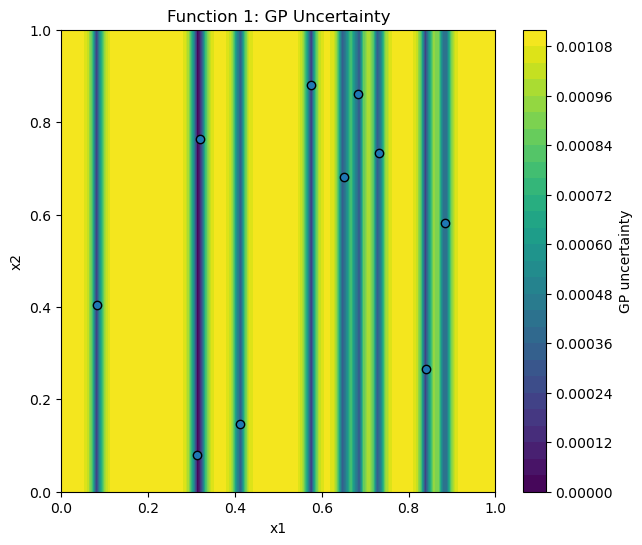

In [44]:
plt.figure(figsize=(7, 6))

plt.contourf(
    xx1,
    xx2,
    std.reshape(xx1.shape),
    levels=30
)

plt.colorbar(label="GP uncertainty")

plt.scatter(
    df["x1"],
    df["x2"],
    edgecolor="black"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Function 1: GP Uncertainty")

plt.show()